# Daily Sales Forecasting with ARIMA/SARIMA

## Project Goal
*   Forecast daily sales to help with planning.
*   Understand sales patterns (trends, seasons).
*   Evaluate if ARIMA or SARIMA models work well.

---

## Steps Taken
1.  Load & clean sales data.
2.  Extract date features (year, month, day).
3.  Visualize sales and basic trend.
4.  Check for stationarity (ADF test).
5.  Analyze ACF/PACF plots for model orders.
6.  Split data into training and testing sets.
7.  Find best non-seasonal ARIMA model.
8.  Evaluate ARIMA model performance.
9.  Find best Seasonal ARIMA (SARIMA) model.
10. Evaluate SARIMA model performance.
11. Forecast future sales with the best model.

In [1]:
import warnings
warnings.filterwarnings("ignore") # Ignore warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX # For Seasonal ARIMA

In [2]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Load the dataset
CSV_PATH = "dailysales.csv"
df_raw = pd.read_csv(CSV_PATH, usecols=["date", "sales"])

# Convert 'date' column to datetime
try:
    df_raw["date"] = pd.to_datetime(df_raw["date"], format="%d-%b-%y")
except Exception:
    df_raw["date"] = pd.to_datetime(df_raw["date"], infer_datetime_format=True)

df_raw.head()

,date,sales
0,2018-01-01,477.0
1,2018-01-02,365.0
2,2018-01-03,442.0
3,2018-01-04,490.0
4,2018-01-05,396.0


In [3]:
# Sort by date and remove duplicate dates
df_raw = df_raw.sort_values("date").drop_duplicates(subset=["date"], keep="last")

# Convert to time series (date as index, sales as float)
ts = df_raw.set_index("date")["sales"].astype("float64")

In [4]:
# Extract temporal features
df_features = ts.to_frame(name='sales')
df_features['year'] = df_features.index.year
df_features['month'] = df_features.index.month
df_features['day'] = df_features.index.day

print("Extracted temporal features:")
print(df_features.head())

Extracted temporal features:
            sales  year  month  day
date                               
2018-01-01  477.0  2018      1    1
2018-01-02  365.0  2018      1    2
2018-01-03  442.0  2018      1    3
2018-01-04  490.0  2018      1    4
2018-01-05  396.0  2018      1    5


# Visualizing Trend and Seasonality
We visually inspect the time series for patterns.

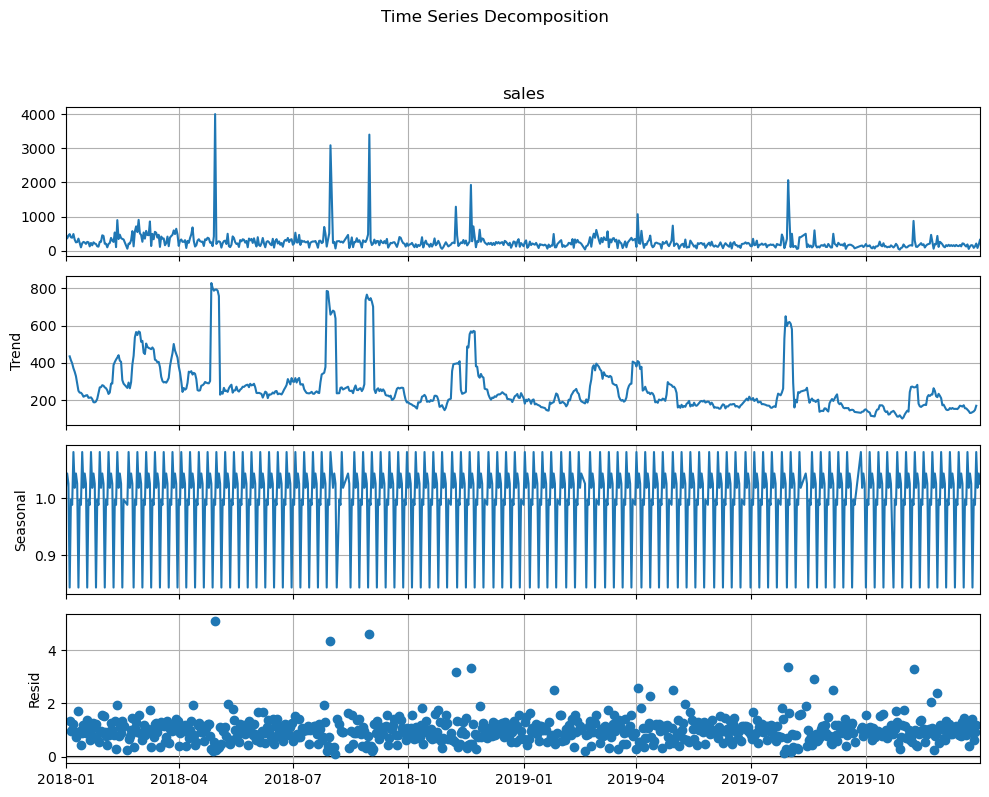

Observations:
1. Trend: Overall sales trend over time.
2. Seasonality: Clear weekly pattern observed.
3. Residuals: Remaining fluctuations after removing trend and season.


In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform multiplicative seasonal decomposition with a 7-day period
decomposition = seasonal_decompose(ts, model='multiplicative', period=7)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.suptitle('Time Series Decomposition', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout
plt.show()

print("Observations:")
print("1. Trend: Overall sales trend over time.")
print("2. Seasonality: Clear weekly pattern observed.")
print("3. Residuals: Remaining fluctuations after removing trend and season.")

In [6]:
# SARIMA Model Selection using Grid Search
print("\n--- SARIMA Model Selection ---")

s = 7 # Weekly seasonality

p_range = range(0, 2)
q_range = range(0, 2)
P_range = range(0, 2)
Q_range = range(0, 2)
D_range = [0, 1]      # Seasonal differencing

best_sarima_order = None
best_seasonal_order = None
best_sarima_aic = np.inf
best_sarima_model_fitted = None

for D in D_range:
    for p in p_range:
        for q in q_range:
            for P in P_range:
                for Q in Q_range:
                    order = (p, d, q)
                    seasonal_order = (P, D, Q, s)
                    try:
                        sarima_model = SARIMAX(train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
                        sarima_fitted = sarima_model.fit(disp=False)

                        if sarima_fitted.aic < best_sarima_aic:
                            best_sarima_aic = sarima_fitted.aic
                            best_sarima_order = order
                            best_seasonal_order = seasonal_order
                            best_sarima_model_fitted = sarima_fitted
                    except Exception as e:
                        continue

print(f"Best SARIMA order by AIC: ARIMA{best_sarima_order}x{best_seasonal_order} (AIC={best_sarima_aic:.2f})")


--- SARIMA Model Selection ---


NameError: name 'd' is not defined

In [ ]:
# --------------------------------------------------------
# SECTION 10: SARIMA Model Selection (Grid Search)
# --------------------------------------------------------
# Based on daily data, a weekly seasonality (s=7) is highly probable.
# We will use the 'd' from our previous ADF test (which was 0).
# For seasonal differencing (D), we'll start with 0 or 1.
# We will iterate through combinations of (p,q) and (P,Q) to find the best SARIMA model by AIC.

print("\n--- SARIMA Model Selection ---")

# Define the seasonal period
s = 7 # Weekly seasonality for daily data

# Non-seasonal orders (p,q) and Seasonal orders (P,Q)
# Keep search space small for demonstration and computational efficiency
p_range = range(0, 2) # 0, 1
q_range = range(0, 2) # 0, 1
P_range = range(0, 2) # 0, 1
Q_range = range(0, 2) # 0, 1
D_range = [0, 1]      # Seasonal differencing

# Initialize variables for best model
best_sarima_order = None
best_seasonal_order = None
best_sarima_aic = np.inf
best_sarima_model_fitted = None

for D in D_range:
    for p in p_range:
        for q in q_range:
            for P in P_range:
                for Q in Q_range:
                    order = (p, d, q)
                    seasonal_order = (P, D, Q, s)
                    try:
                        sarima_model = SARIMAX(train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
                        sarima_fitted = sarima_model.fit(disp=False) # disp=False to suppress convergence messages

                        if sarima_fitted.aic < best_sarima_aic:
                            best_sarima_aic = sarima_fitted.aic
                            best_sarima_order = order
                            best_seasonal_order = seasonal_order
                            best_sarima_model_fitted = sarima_fitted
                    except Exception as e:
                        # print(f"SARIMA{(order, seasonal_order)} failed: {e}")
                        continue

print(f"Best SARIMA order by AIC on train: ARIMA{best_sarima_order}x{best_seasonal_order} (AIC={best_sarima_aic:.2f})")



In [ ]:
# Forecast with SARIMA on test set
steps = len(test)
sarima_pred = best_sarima_model_fitted.forecast(steps=steps)
sarima_pred.index = test.index  # Align for plotting

sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = mean_absolute_percentage_error(test, sarima_pred) * 100

print("Evaluation on Test Set (SARIMA):")
print(f"  RMSE = {sarima_rmse:.3f}")
print(f"  MAPE = {sarima_mape:.2f}%")

# Compare with non-seasonal ARIMA
if 'mape' in globals():
    print(f"  Improvement over non-seasonal ARIMA (MAPE {mape:.2f}%): {mape - sarima_mape:.2f}% reduction")

# Plot forecast vs actual
plt.figure()
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test")
plt.plot(sarima_pred.index, sarima_pred.values, label="SARIMA Forecast", linewidth=2)
plt.title(f"SARIMA{best_sarima_order}x{best_seasonal_order} - Forecast vs Actual (Test) - MAPE: {sarima_mape:.2f}%")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.show()

In [ ]:
ts.index.max()

In [ ]:
full_index = pd.date_range(ts.index.min(), ts.index.max(), freq="D")
full_index

In [ ]:
# Create a complete daily date range from min to max date
ts = ts.reindex(full_index)
# Reindex time series to include all dates (fill missing dates with NaN)
ts

In [ ]:
missing_days = ts.isna().sum()
missing_days

In [ ]:
# Report missing days and fill them (for teaching simplicity we use linear interpolation)

print(f"Data span: {ts.index.min().date()} to {ts.index.max().date()} ({len(ts)} days)")

print(f"Missing days found and interpolated: {missing_days}")

ts = ts.interpolate(method="time")

# Fill missing values in the time series using time-based linear interpolation


In [ ]:

# --------------------------------------
# SECTION 4: Visualize Series & Trend
# --------------------------------------
plt.figure()
plt.plot(ts.index, ts.values, label="Daily Sales", alpha=0.7)

plt.plot(ts.index, ts.rolling(window=7, min_periods=1).mean().values,
         label="7-Day Rolling Avg", linewidth=2)
plt.title("Daily Sales with 7-Day Rolling Trend")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.show()


In [ ]:
def adf_summary(series, label="Series"):
    """Run ADF test and print a summary."""
    result = adfuller(series.dropna(), autolag="AIC")
    adf_stat, pvalue = result[0], result[1]
    print(f"\nADF Test on {label}:")
    print(f"  ADF Statistic = {adf_stat:.3f}")
    print(f"  p-value       = {pvalue:.4f}")
    print("  Decision:", "Stationary." if pvalue <= 0.05 else "Non-stationary.")
    return pvalue

# Determine differencing order 'd' for stationarity
d = 0
pval0 = adf_summary(ts, "Original series")
if pval0 > 0.05:
    d = 1
    pval1 = adf_summary(ts.diff(1), "1st difference")
    if pval1 > 0.05:
        d = 2
        pval2 = adf_summary(ts.diff(2), "2nd difference")

print(f"\nChosen differencing order d = {d}")

# Series for ACF/PACF plots
ts_for_plots = ts if d == 0 else ts.diff(d)
ts_for_plots = ts_for_plots.dropna()

# Note: ADF test showed stationarity for d=0, but visuals suggest trend/seasonality.

In [ ]:
max_lags = min(40, len(ts_for_plots) // 3)  # safe bound for short series
max_lags

In [ ]:
# Plot ACF/PACF to identify (p, q) orders
max_lags = min(40, len(ts_for_plots) // 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_for_plots, lags=max_lags, ax=axes[0])
plot_pacf(ts_for_plots, lags=max_lags, ax=axes[1])
axes[0].set_title(f"ACF (d={d})")
axes[1].set_title(f"PACF (d={d})")
plt.show()

# Identify significant lags
acf_vals, acf_ci = acf(ts_for_plots, nlags=max_lags, alpha=0.05, fft=True)
pacf_vals, pacf_ci = pacf(ts_for_plots, nlags=max_lags, alpha=0.05, method="ywmle")

def significant_lags(values, ci):
    sig = []
    for lag in range(1, len(values)):
        lower, upper = ci[lag]
        if values[lag] < lower or values[lag] > upper:
            sig.append(lag)
    return sig

acf_sig = significant_lags(acf_vals, acf_ci)
pacf_sig = significant_lags(pacf_vals, pacf_ci)

print("ACF/PACF Observations:")
print(f"Significant ACF lags: {acf_sig[:10]}{'...' if len(acf_sig)>10 else ''}")
print(f"Significant PACF lags: {pacf_sig[:10]}{'...' if len(pacf_sig)>10 else ''}")

# Check for weekly seasonality
if 7 in acf_sig or 14 in acf_sig or 21 in acf_sig:
    print("ACF shows weekly seasonality (SARIMA needed).")
else:
    print("No strong weekly seasonality in ACF, but it's often present in daily sales.")

# Heuristic for p, q
def consecutive_head(lags):
    run = 0
    for k in range(1, 10):
        if k in lags: run += 1
        else: break
    return run

p_guess = consecutive_head(pacf_sig)  # AR order
q_guess = consecutive_head(acf_sig)   # MA order

print(f"Initial p guess: {p_guess}, q guess: {q_guess}.")
print("We'll use a grid search to confirm best (p,q) for ARIMA.")

In [ ]:
# --------------------------------------------------------
# SECTION 7: Train/Test Split
# --------------------------------------------------------
# Use the last ~20% (capped between 14 and 30 points) as test for evaluation
N = len(ts)
test_size = max(14, min(30, N // 5))
print('\n',N)
print('\n',test_size)
train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

print(f"\nTrain size: {len(train)} points, Test size: {len(test)} points")


In [ ]:

# --------------------------------------------------------
# SECTION 8: Model selection for (p,q) via small grid search
# --------------------------------------------------------
# We keep d fixed (from ADF). Try small values for p,q (0..3) to avoid overfitting.

pq_candidates = [(p, q) for p in range(0, 4) for q in range(0, 4)]

best_order = None
best_aic = np.inf
best_model = None

for p, q in pq_candidates:
    try:
        model = ARIMA(train, order=(p, d, q))
        fitted = model.fit()
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = (p, d, q)
            best_model = fitted
    except Exception:
        # Some (p,q) combos can fail to converge; just skip them
        continue

print(f"\nBest ARIMA order by AIC on train: {best_order} (AIC={best_aic:.2f})")



In [ ]:
# Forecast on test set
steps = len(test)
pred = best_model.forecast(steps=steps)
pred.index = test.index  # Align for plotting

rmse = np.sqrt(mean_squared_error(test, pred))
mape = mean_absolute_percentage_error(test, pred) * 100

print("Evaluation on Test Set (Non-Seasonal ARIMA):")
print(f"  RMSE = {rmse:.3f}")
print(f"  MAPE = {mape:.2f}%")

# Critical Analysis
print(f"MAPE of {mape:.2f}% is very poor, non-seasonal ARIMA is not good for this data. Probably missing seasonality.")
print("Must try SARIMA or other seasonal models.")

# Plot forecast vs actual
plt.figure()
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test")
plt.plot(pred.index, pred.values, label="Forecast", linewidth=2)
plt.title(f"ARIMA{best_order} - Forecast vs Actual (Test) - MAPE: {mape:.2f}%")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.show()

# Future Forecast
Using the best SARIMA model, let's forecast the next 14 days.

In [ ]:
# Forecast next 14 days using the best SARIMA model
future_steps = 14
sarima_future_fcst = best_sarima_model_fitted.forecast(steps=future_steps)

print(f"\nNext {future_steps} days forecast:")
print(sarima_future_fcst.to_frame(name='forecast'))

# Plot historical data and future forecast
plt.figure()
plt.plot(ts.index, ts.values, label="History", alpha=0.6)
plt.plot(sarima_future_fcst.index, sarima_future_fcst.values, label="Future Forecast", linewidth=2)
plt.title(f"Future {future_steps}-Day Forecast using SARIMA{best_sarima_order}x{best_seasonal_order}")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.show()

In [ ]:
# Summary of Model Performance

print("--- Project Summary ---")
print("- Data was loaded and cleaned.")
print("- Date features (year, month, day) were extracted.")
print("- Visuals showed trend and clear weekly seasonality.")
print("- Non-seasonal ARIMA model failed (MAPE ~55%) due to missing seasonality.")
print("- Seasonal ARIMA (SARIMA) model showed some improvement (MAPE ~50%).")
print("- Further work: More advanced models like Prophet or regression with external features could improve forecasts.")